<center>
  <h1 style="background-color: #80dfffff; color: #137a91ff; padding: 10px">
    <strong>Model Development</strong>
  </h1>
</center>

**Student ID's:**

Andreea Roica: 20250361

Beatriz Varela: 20250367

Barbara Franco: 20250388

Marisa Esteves: 20250348

#
<h2 style="background-color: #80dfffff; color: #137a91ff; padding: 5px; margin: 5px;">
<strong>Index</strong>
</h2>


[1. **Pre Processing**](#1st-bullet)<br>

[2. **Pipeline**](#2nd-bullet)<br>

[3. **Fine Tuning**](#3rd-bullet)<br>

[4. **Model Comparison**](#9th-bullet)<br>

[5. **Ablation Study**](#10th-bullet)<br>

[6. **Feature Importance**](#11th-bullet)<br>
    

#
<h2 style="background-color: #80dfffff; color: #137a91ff; padding: 5px; margin: 5px;">
<strong>Imports</strong>
</h2>

Importing the necessary libraries:

In [10]:
!pip install shap

In [118]:
from Classes import *

from functions import *

from sklearn.model_selection import KFold

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.neighbors import KNeighborsRegressor

from sklearn.linear_model import HuberRegressor, LinearRegression

from sklearn.neural_network import MLPRegressor

from sklearn.compose import TransformedTargetRegressor

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import make_scorer

from sklearn.pipeline import Pipeline

import seaborn as sns

import shap

import math

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


Uploading the dataset:

In [12]:
df_train = pd.read_csv('train.csv')

Setting carID as index:

In [13]:
df_train.set_index('carID', inplace=True)

Setting a seed:

In [14]:
random_state = 42

#
<h2 id="1st-bullet" style="background-color: #f7d888ff; color: #da6919ff; padding: 5px; margin: 5px;">
  <strong>  1. Pre Processing</strong>
</h2>


Drop informations given by the mechanic: 

In [15]:
df_train.drop('paintQuality%', axis = 1, inplace=True)

We start by defining the inconsistent values discussed in the EDA as NA:

In [16]:
df_train.loc[df_train['year']>2020, 'year'] = np.nan

df_train.loc[df_train['mileage']<0, 'mileage'] = np.nan

df_train.loc[df_train['tax']<0, 'tax'] = np.nan

df_train.loc[df_train['mpg'] < 8, 'mpg'] = np.nan

df_train.loc[df_train['previousOwners']< 0, 'previousOwners'] = np.nan

df_train.loc[df_train['engineSize'] < 1, 'engineSize'] = np.nan

We proceed to round 'year' and 'previousOwners' to whole numbers using the floor function. Other numerical features are rounded to 2 decimal points.

In [17]:
df_train['year'] = np.floor(df_train['year'])
df_train['previousOwners'] = np.floor(df_train['previousOwners'])

for feat in ['mileage', 'tax', 'mpg', 'engineSize']:
    df_train[feat] = df_train[feat].round(2)

We also pre-process the categorical variables in order to have a uniform format for later treatment (inside k-fold CV). We remove leeading and trailing spaces and uppercase all letters.

In [18]:
# Pre processing the categorical variables to be easier to find clusters in typos:
    # remove spaces (at the beginning and end) and uppercase all letters
    # does not replace NaN's
df_train['Brand'] = df_train['Brand'].where(df_train['Brand'].isna(), df_train['Brand'].astype(str).str.strip().str.upper())

df_train['model'] = df_train['model'].where(df_train['model'].isna(), df_train['model'].astype(str).str.strip().str.upper())

df_train['fuelType'] = df_train['fuelType'].where(df_train['fuelType'].isna(), df_train['fuelType'].astype(str).str.strip().str.upper())

df_train['transmission'] = df_train['transmission'].where(df_train['transmission'].isna(), df_train['transmission'].astype(str).str.strip().str.upper())


The W's in brand could either mean 'BMW' or 'VW'. We already checked that they are all 'VW', so lets correct the W's:

In [19]:
df_train.loc[df_train['Brand'] == 'W', 'Brand'] = 'VW'

Division between input variables (X) and output variable (y):

In [20]:

y = df_train['price']
X = df_train.drop('price', axis=1)


#
<h2 id="2nd-bullet" style="background-color: #f7d888ff; color: #da6919ff; padding: 5px; margin: 5px;">
  <strong>  2. Pipeline</strong>
</h2>


We are going to build a pipeline that is shared by all the models.

This funtion is created here because it uses the classes, therefore it cannot be include in the functions.py file like the others.

In [21]:
def build_pipeline(regressor, use_log=False, target_scaler=None, scaler_instance=None):

    """
    Builds a complete machine learning pipeline for regression tasks. 
    The pipeline allows different regressors, scaling strategies and optional log-transformation or scaling of the target variable.

    Parameters
    ----------
    regressor: 
        Regression model used as the final estimator.

    use_log: boolean 
        Indicates whether to apply log-transformation to the target variable.

    target_scaler: scaler object
        Scaler applied to the target variable. Default is None (no target scaling).

    scaler_instance: scaler object 
        Scaler object passed to the scaling step.

    Returns
    -------
    sklearn.pipeline.Pipeline
        A machine learning pipeline with preprocessing, feature engineering, feature selection, and regression steps.
    """

    if use_log:
        final_reg = TransformedTargetRegressor(regressor=regressor,
                                               func=np.log,
                                               inverse_func=np.exp)

    elif target_scaler is not None:
        final_reg = TransformedTargetRegressor(
            regressor=regressor,
            transformer=target_scaler
        )
        
    else:
        final_reg = regressor

    return Pipeline([
        ('categorical_treatment', Categorical_Correction()),
        ('outlier_treatment', Outlier_Treatment()),
        ('missing_value_treatment', Missing_Value_Treatment()),
        ('typecasting', Typecasting()),
        ('feature_engineering', Feature_Engineering()),
        ('encoder', Encoder()),
        ('scaler', Scaler(scaler=scaler_instance)),
        ('feature_selection', Feature_Selection()),
        ('regressor', final_reg)
    ])

We will scale the target feature for MLP with sgd, since large values of this variable can result in really high gradients causing unstable weight updates which tend to not converge, originating NA values. This way the model is stable and has controlled updates.

#
<h2 id="3rd-bullet" style="background-color: #f7d888ff; color: #da6919ff; padding: 5px; margin: 5px;">
  <strong>  3. Fine Tuning</strong>
</h2>


We are going to create a model dictionary that defines the regressor instance and the hyperparameter search space.

For every model, we tested four different types of scaling, RobustScaler, MinMaxScaler, MinMaxScaler with feature range from -1 to 1 and Standard Scaler. We previously tested the models with a logarithmic transformation on the target variable and based on those results we decided to apply it to the KNN and GradientBoosting models (we do not include this testing in the code, for computational efficiency).

We create separate dictionaries for MLP with adam and MLP with sgd because with the sgd solver there are several more combinations of parameters which would result in a very unbalanced selection between the solvers while tuning.

In [22]:
models_testing = {
    "KNN": {
        "regressor": KNeighborsRegressor(),
        "use_log": True,
        "param_distributions": {
            'feature_selection__rfe_k': list(range(5,15)),
            'feature_selection__spearman_thr': [0.2, 0.25, 0.3],
            'regressor__regressor__n_neighbors': np.arange(1, 100),
            'regressor__regressor__weights': ['uniform', 'distance'],
            'regressor__regressor__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
            'regressor__regressor__metric': ['minkowski', 'manhattan', 'euclidean', 'chebyshev'],
            'regressor__regressor__p': [1, 1.5, 2, 3, 4],
            'scaler__scaler': [StandardScaler(), MinMaxScaler(feature_range=(0,1)), MinMaxScaler(feature_range=(-1,1)), RobustScaler()]
        }
    },

    "GradientBoosting": {
        "regressor": GradientBoostingRegressor(),
        "use_log": True,
        "param_distributions": {
            'feature_selection__rfe_k': list(range(5,15)),
            'feature_selection__spearman_thr': [0.2, 0.25, 0.3],
            'regressor__regressor__max_features': [0.4, 0.5, 0.6],
            'regressor__regressor__loss': ['absolute_error', 'huber'],
            'regressor__regressor__n_estimators': [700, 900, 1100],
            'regressor__regressor__max_depth': [6, 7, 8, 9], 
            'regressor__regressor__learning_rate': [0.02, 0.03, 0.04, 0.05],
            'regressor__regressor__subsample': [0.75, 0.8],
            'regressor__regressor__min_samples_split': [4, 5, 6],
            'regressor__regressor__min_samples_leaf': [3, 4],
            'regressor__regressor__criterion': ['squared_error'],
            'regressor__regressor__min_impurity_decrease': [0.0, 0.0001, 0.0005],
            'regressor__regressor__max_leaf_nodes': [None, 30, 40],
            'regressor__regressor__n_iter_no_change': [None, 10, 15],
            'regressor__regressor__validation_fraction': [0.15, 0.2],
            'scaler__scaler': [StandardScaler(), MinMaxScaler(feature_range=(0,1)), MinMaxScaler(feature_range=(-1,1)), RobustScaler()]
        }
    },

    "RandomForest": {
        "regressor": RandomForestRegressor(),
        "use_log": False,
        "param_distributions": {
            'feature_selection__rfe_k': list(range(5,15)),
            'feature_selection__spearman_thr': [0.2, 0.25, 0.3],
            'regressor__n_estimators': [400,300],
            'regressor__min_samples_split': [24,25,26,30,35],  
            'regressor__min_samples_leaf': [2,3,4],   
            'regressor__max_features': [0.5, 'sqrt'],
            'regressor__max_depth': [18,19,20],         
            'regressor__min_impurity_decrease': [0.001, 0.0005],
            'regressor__ccp_alpha':[0.00005, 0.0001],
            'regressor__max_samples': [0.75, 0.80],
            'regressor__criterion': ['squared_error'], #default
            'regressor__bootstrap': [True], #default
            'scaler__scaler': [StandardScaler(), MinMaxScaler(feature_range=(0,1)), MinMaxScaler(feature_range=(-1,1)), RobustScaler()]
        }
    },

    "MLP_sgd": {
        "regressor" : MLPRegressor(),
        "use_log" : False,
        "target_scaler": StandardScaler(),
        "param_distributions" : { 
            'feature_selection__rfe_k': list(range(5,15)),
            'feature_selection__spearman_thr': [0.2, 0.25, 0.3],
            'regressor__regressor__solver' : ['sgd'],
            'regressor__regressor__hidden_layer_sizes' : [(32,16),(100,50), (150,70), (200,100), (100,50,25), (200,100,50)],
            'regressor__regressor__max_iter' :  [300],
            'regressor__regressor__activation' : ['relu', 'tanh', 'logistic'],
            'regressor__regressor__learning_rate' :  ['constant','invscaling','adaptive'],
            'regressor__regressor__learning_rate_init' : [0.01, 0.001, 0.0001, 0.00001],
            'regressor__regressor__batch_size' : [100, 200, 300],
            'regressor__regressor__alpha': [1e-6, 1e-5, 1e-4, 1e-3],
            'scaler__scaler': [StandardScaler(), MinMaxScaler(feature_range=(0,1)), MinMaxScaler(feature_range=(-1,1)), RobustScaler()]
        }
    },

    "MLP_adam": {
            "regressor" : MLPRegressor(),
            "use_log" : False,
            "param_distributions" : { 
                'feature_selection__rfe_k': list(range(5,15)),
                'feature_selection__spearman_thr': [0.2, 0.25, 0.3],
                'regressor__solver' : ['adam'],
                'regressor__hidden_layer_sizes' : [(32,16), (200, 100), (400, 200), (100,50,25)],
                'regressor__max_iter' :  [700],
                'regressor__activation' : ['relu', 'tanh', 'logistic'],
                'regressor__learning_rate_init' : [0.001, 0.01, 0.1],
                'scaler__scaler': [StandardScaler(), MinMaxScaler(feature_range=(0,1)), MinMaxScaler(feature_range=(-1,1)), RobustScaler()]
        }
    },


    "Huber": {
            "regressor" : HuberRegressor(),
            "use_log" : False,
            "param_distributions" : { 
                    'feature_selection__rfe_k': list(range(5,15)),
                    'feature_selection__spearman_thr': [0.2, 0.25, 0.3],
                    'regressor__epsilon': [1.1, 1.2, 1.35, 1.5, 2.0, 2.5, 3.0],
                    'regressor__alpha': [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1.0, 10.0],
                    'regressor__fit_intercept': [True],
                    'regressor__max_iter': [500, 1000, 2000],
                    'scaler__scaler': [StandardScaler(), MinMaxScaler(feature_range=(0,1)), MinMaxScaler(feature_range=(-1,1)), RobustScaler()]
        }
    },

    "Decision Tree": {
            "regressor" : DecisionTreeRegressor(),
            "use_log" : False,
            "param_distributions" : { 
                    'feature_selection__rfe_k': list(range(5,15)),
                    'feature_selection__spearman_thr': [0.2, 0.25, 0.3],
                    'regressor__max_depth': [5, 10, 15, 20, None],
                    'regressor__min_samples_split': [5, 6, 7, 8, 9, 10],
                    'regressor__min_samples_leaf': [5, 6, 7],
                    'regressor__criterion': ['absolute_error'],
                    'regressor__min_impurity_decrease': [0.0001, 0.0005, 0.001],
                    'regressor__max_features': ['sqrt', 0.5, 0.2],  
                    'regressor__max_leaf_nodes': [None, 20, 50, 100],
                    'scaler__scaler': [StandardScaler(), MinMaxScaler(feature_range=(0,1)), MinMaxScaler(feature_range=(-1,1)), RobustScaler()]  

        }
     }

}

### Randomized Search

This funtion is created here because it uses build_pipeline, therefore it cannot be include in the functions.py file like the others.

In [23]:
def run_model_search(name, cfg, X, y, n_iter=2, cv=5, random_state=42):

    """
    Runs a RandomizedSearchCV for hyperparameter tuning of a regression model pipeline.

    Parameters
    ----------
    name : str
        The name of the model being evaluated.

    cfg : dict
        Configuration dictionary containing:    
        - 'regressor': The regression model to be used in the pipeline. 
        - 'use_log': Boolean indicating whether to apply log transformation to the target variable.
        - 'target_scaler': Scaler applied to the target variable. 
            If not specified, no scaling is applied.
        - 'param_distributions': Dictionary of hyperparameter distributions for RandomizedSearchCV.
    
    X : pandas.DataFrame
        Feature matrix used for training the model.

    y : pandas.Series
        Target variable (price).

    n_iter : int, default=2
        Number of parameter settings that are sampled in RandomizedSearchCV.

    cv : int, default=5
        Number of cross-validation folds.

    random_state : int, default=42
        Random seed for reproducibility.

    Returns
    -------
    dict
        A dictionary containing:
        - 'Model': The name of the model.
        - 'Use_Log': Boolean indicating if log transformation was used.
        - 'Target_Scaled': Boolean indicating if target variable was scaled.
        - 'Search_Object': The fitted RandomizedSearchCV object.
        - 'CV_Results': DataFrame with cross-validation results and additional metrics.

    """
    scoring = { 'R2': 'r2', 
    'MAE': 'neg_mean_absolute_error',
    'MAPE': 'neg_mean_absolute_percentage_error',
    'MedAE': 'neg_median_absolute_error',
    'RMSE': 'neg_root_mean_squared_error'}

    print(f"\n=== Running: {name} (use_log={cfg['use_log']}) ===")

    pipeline = build_pipeline(cfg['regressor'], use_log=cfg['use_log'], target_scaler=cfg.get('target_scaler', None))
    params = cfg['param_distributions']

    num_config = math.prod(len(v) for v in params.values())
    n_iter = min(n_iter, num_config)

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=params,
        n_iter=n_iter,
        scoring=scoring,
        refit='MAE',
        cv=KFold(n_splits=cv, shuffle=True, random_state=random_state),
        verbose=2,
        return_train_score=True,
        random_state=random_state,
        n_jobs=-1
    )
    t0 = time.time()
    search.fit(X, y)
    t_elapsed = time.time() - t0

    cv_results_df = pd.DataFrame(search.cv_results_)
    
    cv_results_df['overfit_mae'] = (cv_results_df['mean_test_MAE'] - cv_results_df['mean_train_MAE']) / cv_results_df['mean_train_MAE'] * 100
    cv_results_df['overfit_R2'] = (cv_results_df['mean_test_R2'] - cv_results_df['mean_train_R2']) / cv_results_df['mean_train_R2'] * 100
    cv_results_df['Model'] = name
    cv_results_df['Use_Log'] = cfg['use_log']
    cv_results_df['Execution_Time_s'] = t_elapsed

    result = {
        'Model': name,
        'Use_Log': cfg['use_log'],
        'Target_Scaled': cfg.get('target_scaler', None) is not None,
        'Search_Object': search,
        'CV_Results': cv_results_df
    }
    return result

### Loop through all models

After collecting all CV results from every model, we are going to rank all hyperparameter combinations by lowest test MAE and display the top 50 best-performing configurations.

In [24]:
all_results = []
for model_name, cfg in models_testing.items():
    res = run_model_search(model_name, cfg, X, y, n_iter=40, cv=5, random_state=random_state)
    all_results.append(res)

all_cv_summary = pd.concat([r['CV_Results'] for r in all_results], ignore_index=True)

all_cv_summary['mean_train_MAE_pos'] = -all_cv_summary['mean_train_MAE']
all_cv_summary['mean_test_MAE_pos'] = -all_cv_summary['mean_test_MAE']

all_cv_summary.to_csv("all_cv_summary.csv", index=True)

top_50_cv_summary = all_cv_summary.sort_values('mean_test_MAE_pos', ascending=True).head(50)

top_50_cv_summary.to_csv("top_50_cv_summary.csv", index=True)


=== Running: KNN (use_log=True) ===
Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV] END feature_selection__rfe_k=5, feature_selection__spearman_thr=0.25, regressor__regressor__algorithm=brute, regressor__regressor__metric=euclidean, regressor__regressor__n_neighbors=79, regressor__regressor__p=4, regressor__regressor__weights=distance, scaler__scaler=MinMaxScaler(feature_range=(-1, 1)); total time= 1.1min
[CV] END feature_selection__rfe_k=5, feature_selection__spearman_thr=0.25, regressor__regressor__algorithm=brute, regressor__regressor__metric=euclidean, regressor__regressor__n_neighbors=79, regressor__regressor__p=4, regressor__regressor__weights=distance, scaler__scaler=MinMaxScaler(feature_range=(-1, 1)); total time= 1.1min
[CV] END feature_selection__rfe_k=5, feature_selection__spearman_thr=0.25, regressor__regressor__algorithm=brute, regressor__regressor__metric=euclidean, regressor__regressor__n_neighbors=79, regressor__regressor__p=4, regressor__regressor__

In [25]:

print("=== Top 50 hyperparameter combinations with lowest CV MAE ===")
display(top_50_cv_summary[[
    'Model', 'Use_Log', 'params',
    'mean_train_MAE_pos', 'mean_test_MAE_pos',
    'mean_train_R2', 'mean_test_R2',
    'mean_train_MAPE', 'mean_test_MAPE',
    'mean_train_MedAE', 'mean_test_MedAE',
    'mean_train_RMSE', 'mean_test_RMSE',
    'overfit_mae', 'overfit_R2'
]])


=== Top 50 hyperparameter combinations with lowest CV MAE ===


,Model,Use_Log,params,mean_train_MAE_pos,mean_test_MAE_pos,mean_train_R2,mean_test_R2,mean_train_MAPE,mean_test_MAPE,mean_train_MedAE,mean_test_MedAE,mean_train_RMSE,mean_test_RMSE,overfit_mae,overfit_R2
51,GradientBoosting,True,"{'scaler__scaler': RobustScaler(), 'regressor_...",1262.340988,1346.783091,0.949496,0.940042,-0.077895,-0.083287,-8.156540e+02,-857.693167,-2188.085372,-2379.242710,6.689326,-0.995741
104,RandomForest,False,{'scaler__scaler': MinMaxScaler(feature_range=...,1189.512011,1355.735228,0.951471,0.934766,-0.075172,-0.085767,-7.544752e+02,-846.796586,-2144.924983,-2481.135126,13.974068,-1.755700
15,KNN,True,"{'scaler__scaler': RobustScaler(), 'regressor_...",50.657930,1357.159354,0.998891,0.934079,-0.004350,-0.085089,-7.275958e-12,-825.009048,-324.180493,-2489.654143,2579.065971,-6.488445
102,RandomForest,False,"{'scaler__scaler': MinMaxScaler(), 'regressor_...",1201.796876,1362.234706,0.949160,0.933259,-0.075829,-0.086045,-7.589422e+02,-849.001456,-2195.394209,-2509.491376,13.349829,-1.675241
112,RandomForest,False,"{'scaler__scaler': MinMaxScaler(), 'regressor_...",1210.399958,1365.403869,0.949958,0.934007,-0.076443,-0.086399,-7.688006e+02,-853.421649,-2178.088052,-2495.523811,12.806008,-1.679152
83,RandomForest,False,{'scaler__scaler': MinMaxScaler(feature_range=...,1215.428445,1368.854884,0.949539,0.933939,-0.076814,-0.086696,-7.727441e+02,-856.637478,-2187.156063,-2496.947644,12.623239,-1.642964
110,RandomForest,False,"{'scaler__scaler': RobustScaler(), 'regressor_...",1217.637191,1370.263083,0.949230,0.933481,-0.076903,-0.086692,-7.718357e+02,-853.694828,-2193.881498,-2505.656621,12.534595,-1.659157
82,RandomForest,False,"{'scaler__scaler': StandardScaler(), 'regresso...",1217.483148,1371.037617,0.947823,0.932396,-0.076872,-0.086647,-7.680149e+02,-852.640261,-2224.082162,-2525.879095,12.612451,-1.627600
89,RandomForest,False,{'scaler__scaler': MinMaxScaler(feature_range=...,1214.839735,1371.539382,0.949434,0.933232,-0.076739,-0.086728,-7.695440e+02,-857.647165,-2189.413227,-2509.555630,12.898792,-1.706505
90,RandomForest,False,"{'scaler__scaler': RobustScaler(), 'regressor_...",1218.751321,1372.241960,0.948203,0.932713,-0.076907,-0.086730,-7.697600e+02,-853.567387,-2215.937811,-2519.858950,12.594090,-1.633584


#
<h2 id="4th-bullet" style="background-color: #f7d888ff; color: #da6919ff; padding: 5px; margin: 5px;">
  <strong>  4. Model Comparison</strong>
</h2>

In this section we will be evaluating model performance and picking the best model. For this, we will take into account the following criteria:
- for each each model we will be picking the best parameters based on their test performance and overfitting/underfitting 
- MAE, R2, MedAE metrics will be computed and prioritized 
- for each model we will choose the set of parameters that results in better performance metrics unless there is another set with similar performance and less overfit (we consider models to have similar performance if the difference between their test MAE is below 50)
- we will establish an overfitting limit between 15% and 20% since from that point on the model becomes unreliable
- in the end, we will compare all models and pick the best one according to the same logic


Additionally, for model analysis, MAE, MedAE, and R² were prioritized to provide a comprehensive evaluation of model performance. MAE was selected for its interpretability, as it express the average prediction error in the same unit as the target variable, allowing for a direct assessment of practical impact. MedAE was included due to its robustness to outliers, offering a reliable measure of the typical prediction error in datasets that may contain extreme values, like ours. Finally, R² was used to assess the proportion of variance in the target variable explained by the model, providing insight into its overall explanatory power. Together, these metrics ensure a balanced evaluation by capturing accuracy, robustness, and goodness of fit

### **KNN**

In [37]:
top_50_cv_summary.loc[top_50_cv_summary['Model']=='KNN', ['Model', 'Use_Log', 'params',
    'mean_train_MAE_pos', 'mean_test_MAE_pos',
    'mean_train_R2', 'mean_test_R2',
    'mean_train_MedAE', 'mean_test_MedAE',
    'overfit_mae', 'overfit_R2']].head(8)

,Model,Use_Log,params,mean_train_MAE_pos,mean_test_MAE_pos,mean_train_R2,mean_test_R2,mean_train_MedAE,mean_test_MedAE,overfit_mae,overfit_R2
15,KNN,True,"{'scaler__scaler': RobustScaler(), 'regressor_...",50.657930,1357.159354,0.998891,0.934079,-7.275958e-12,-825.009048,2579.065971,-6.488445
3,KNN,True,{'scaler__scaler': MinMaxScaler(feature_range=...,44.487456,1405.265213,0.999016,0.926331,-7.275958e-12,-857.894528,3058.789793,-7.275653
21,KNN,True,"{'scaler__scaler': RobustScaler(), 'regressor_...",47.887806,1412.456640,0.998964,0.927128,-7.275958e-12,-855.724404,2849.512124,-7.191051
28,KNN,True,"{'scaler__scaler': StandardScaler(), 'regresso...",69.017445,1455.896731,0.997678,0.919185,-7.275958e-12,-867.773020,2009.461935,-7.867546
33,KNN,True,"{'scaler__scaler': StandardScaler(), 'regresso...",83.426023,1489.118249,0.997607,0.912264,-7.275958e-12,-881.381745,1684.956540,-8.554761
11,KNN,True,{'scaler__scaler': MinMaxScaler(feature_range=...,40.405194,1505.531334,0.999121,0.910328,-7.275958e-12,-904.862687,3626.083643,-8.887089
19,KNN,True,"{'scaler__scaler': StandardScaler(), 'regresso...",114.771572,1509.304189,0.994994,0.909261,-7.275958e-12,-864.930601,1215.050555,-8.616470
34,KNN,True,"{'scaler__scaler': RobustScaler(), 'regressor_...",1420.175271,1528.286795,0.923669,0.912123,-8.593539e+02,-923.557945,7.612548,-1.250024


The results from the KNN models show an extremely high overfit in general, performing much better in the train set. In this case, the choice is obvious, the KNN model at index 34 is the best one of its kind that we have obtained.

### **GradientBoosting**

In [110]:
all_cv_summary.loc[all_cv_summary['Model']=='GradientBoosting', ['Model', 'Use_Log', 'params',
    'mean_train_MAE_pos', 'mean_test_MAE_pos',
    'mean_train_R2', 'mean_test_R2',
    'mean_train_MedAE', 'mean_test_MedAE',
    'overfit_mae', 'overfit_R2']].sort_values(by='mean_test_MAE_pos').head(10)

,Model,Use_Log,params,mean_train_MAE_pos,mean_test_MAE_pos,mean_train_R2,mean_test_R2,mean_train_MedAE,mean_test_MedAE,overfit_mae,overfit_R2
51,GradientBoosting,True,"{'scaler__scaler': RobustScaler(), 'regressor_...",1262.340988,1346.783091,0.949496,0.940042,-815.654049,-857.693167,6.689326,-0.995741
68,GradientBoosting,True,"{'scaler__scaler': RobustScaler(), 'regressor_...",1351.151788,1425.262338,0.932221,0.925620,-829.787893,-880.988331,5.484991,-0.708027
40,GradientBoosting,True,{'scaler__scaler': MinMaxScaler(feature_range=...,1356.669757,1426.719121,0.931525,0.924885,-834.715305,-886.109733,5.163332,-0.712738
70,GradientBoosting,True,"{'scaler__scaler': MinMaxScaler(), 'regressor_...",1401.356017,1457.290442,0.923717,0.918606,-853.837788,-891.698629,3.991450,-0.553320
52,GradientBoosting,True,"{'scaler__scaler': RobustScaler(), 'regressor_...",1435.177930,1486.840777,0.919287,0.913875,-876.679600,-912.042498,3.599752,-0.588702
76,GradientBoosting,True,"{'scaler__scaler': StandardScaler(), 'regresso...",1449.026952,1501.363661,0.918414,0.912873,-884.627965,-916.596658,3.611852,-0.603279
71,GradientBoosting,True,{'scaler__scaler': MinMaxScaler(feature_range=...,1457.784672,1503.511078,0.917014,0.912769,-891.587270,-925.883229,3.136705,-0.462973
54,GradientBoosting,True,"{'scaler__scaler': MinMaxScaler(), 'regressor_...",1456.604540,1522.478500,0.917688,0.911250,-890.369117,-935.713748,4.522433,-0.701566
44,GradientBoosting,True,{'scaler__scaler': MinMaxScaler(feature_range=...,1477.127652,1522.728940,0.915890,0.911430,-907.375932,-936.792374,3.087160,-0.487042
47,GradientBoosting,True,{'scaler__scaler': MinMaxScaler(feature_range=...,1478.505920,1532.877370,0.914288,0.908094,-898.060512,-936.374000,3.677459,-0.677467


In this case, we select the first model (index 51) as the best. It is the one that performs significantly better with a difference of over 50 points in MAE when compared to other models, while still maintaining a reasonable 6.7% difference between train and test MAE performance. It also shows a 1% difference in R2 and performs best out of all the models in MedAE.

### **RandomForest**

In [120]:
all_cv_summary.loc[all_cv_summary['Model']=='RandomForest', ['Model', 'Use_Log', 'params',
    'mean_train_MAE_pos', 'mean_test_MAE_pos',
    'mean_train_R2', 'mean_test_R2',
    'mean_train_MedAE', 'mean_test_MedAE',
    'overfit_mae', 'overfit_R2']].sort_values(by='mean_test_MAE_pos').head(15)

,Model,Use_Log,params,mean_train_MAE_pos,mean_test_MAE_pos,mean_train_R2,mean_test_R2,mean_train_MedAE,mean_test_MedAE,overfit_mae,overfit_R2
104,RandomForest,False,{'scaler__scaler': MinMaxScaler(feature_range=...,1189.512011,1355.735228,0.951471,0.934766,-754.475160,-846.796586,13.974068,-1.755700
102,RandomForest,False,"{'scaler__scaler': MinMaxScaler(), 'regressor_...",1201.796876,1362.234706,0.949160,0.933259,-758.942191,-849.001456,13.349829,-1.675241
112,RandomForest,False,"{'scaler__scaler': MinMaxScaler(), 'regressor_...",1210.399958,1365.403869,0.949958,0.934007,-768.800569,-853.421649,12.806008,-1.679152
83,RandomForest,False,{'scaler__scaler': MinMaxScaler(feature_range=...,1215.428445,1368.854884,0.949539,0.933939,-772.744075,-856.637478,12.623239,-1.642964
110,RandomForest,False,"{'scaler__scaler': RobustScaler(), 'regressor_...",1217.637191,1370.263083,0.949230,0.933481,-771.835704,-853.694828,12.534595,-1.659157
82,RandomForest,False,"{'scaler__scaler': StandardScaler(), 'regresso...",1217.483148,1371.037617,0.947823,0.932396,-768.014855,-852.640261,12.612451,-1.627600
89,RandomForest,False,{'scaler__scaler': MinMaxScaler(feature_range=...,1214.839735,1371.539382,0.949434,0.933232,-769.544032,-857.647165,12.898792,-1.706505
90,RandomForest,False,"{'scaler__scaler': RobustScaler(), 'regressor_...",1218.751321,1372.241960,0.948203,0.932713,-769.760023,-853.567387,12.594090,-1.633584
103,RandomForest,False,"{'scaler__scaler': StandardScaler(), 'regresso...",1229.685342,1376.659217,0.946739,0.931789,-775.846126,-858.358004,11.952153,-1.579135
87,RandomForest,False,"{'scaler__scaler': MinMaxScaler(), 'regressor_...",1233.251852,1385.201682,0.946001,0.930681,-772.867931,-859.201121,12.321071,-1.619396


Out of the RandomForest models, index 104 performed best. It shows very similar results to the models that showed a slightly lover performance (the difference is under 50 in MAE). It also performed best in MedAE. For this reason, and also the fact that the model shows a similar overfitting compared to the remaining, we select it as the best model of its kind.

### **MLP**

In [48]:
mask = (all_cv_summary['Model']=='MLP_sgd') | (all_cv_summary['Model']=='MLP_adam')

all_cv_summary.loc[mask, ['Model', 'Use_Log', 'params',
    'mean_train_MAE_pos', 'mean_test_MAE_pos',
    'mean_train_R2', 'mean_test_R2',
    'mean_train_MedAE', 'mean_test_MedAE',
    'overfit_mae', 'overfit_R2']].sort_values(by='mean_test_MAE_pos').head(10)

,Model,Use_Log,params,mean_train_MAE_pos,mean_test_MAE_pos,mean_train_R2,mean_test_R2,mean_train_MedAE,mean_test_MedAE,overfit_mae,overfit_R2
185,MLP_adam,False,"{'scaler__scaler': MinMaxScaler(), 'regressor_...",1211.941964,1426.602219,0.945739,0.927350,-752.288175,-879.754278,17.712090,-1.944421
161,MLP_adam,False,"{'scaler__scaler': StandardScaler(), 'regresso...",1571.209349,1621.731954,0.924304,0.916295,-1002.775474,-1022.586131,3.215523,-0.866475
189,MLP_adam,False,{'scaler__scaler': MinMaxScaler(feature_range=...,1580.890293,1641.842732,0.925027,0.914082,-1053.365495,-1071.531856,3.855577,-1.183149
175,MLP_adam,False,"{'scaler__scaler': StandardScaler(), 'regresso...",1609.095188,1651.037701,0.916305,0.909420,-1025.033726,-1044.871719,2.606590,-0.751434
187,MLP_adam,False,"{'scaler__scaler': RobustScaler(), 'regressor_...",1522.790740,1666.223873,0.915048,0.899824,-950.870700,-1031.602394,9.419097,-1.663651
186,MLP_adam,False,"{'scaler__scaler': RobustScaler(), 'regressor_...",1630.504235,1673.116413,0.914199,0.905027,-1027.772440,-1048.747993,2.613436,-1.003344
166,MLP_adam,False,"{'scaler__scaler': RobustScaler(), 'regressor_...",1663.435087,1695.477239,0.916560,0.909387,-1093.331673,-1104.258749,1.926264,-0.782589
180,MLP_adam,False,"{'scaler__scaler': RobustScaler(), 'regressor_...",1669.237682,1697.766810,0.920207,0.913244,-1116.754327,-1127.063343,1.709111,-0.756627
121,MLP_sgd,False,"{'scaler__scaler': RobustScaler(), 'regressor_...",1667.046672,1709.856231,0.909015,0.899372,-1043.083495,-1065.764251,2.567988,-1.060875
155,MLP_sgd,False,{'scaler__scaler': MinMaxScaler(feature_range=...,1684.735848,1717.168005,0.918570,0.910444,-1126.146411,-1135.719507,1.925059,-0.884663


From the MLP models, the best one is at index 185 and uses the adam solver. It clearly shows better performance in both train and test in MAE and MedAE although it overfits significantly more. 

### **Huber**

In [49]:
all_cv_summary.loc[all_cv_summary['Model']=='Huber', ['Model', 'Use_Log', 'params',
    'mean_train_MAE_pos', 'mean_test_MAE_pos',
    'mean_train_R2', 'mean_test_R2',
    'mean_train_MedAE', 'mean_test_MedAE',
    'overfit_mae', 'overfit_R2']].sort_values(by='mean_test_MAE_pos').head(10)

,Model,Use_Log,params,mean_train_MAE_pos,mean_test_MAE_pos,mean_train_R2,mean_test_R2,mean_train_MedAE,mean_test_MedAE,overfit_mae,overfit_R2
223,Huber,False,"{'scaler__scaler': RobustScaler(), 'regressor_...",2513.334798,2518.077855,0.798930,0.797491,-1663.144660,-1664.592201,0.188716,-0.180146
222,Huber,False,{'scaler__scaler': MinMaxScaler(feature_range=...,2523.166954,2529.025150,0.803210,0.801457,-1693.092965,-1697.071820,0.232176,-0.218252
226,Huber,False,{'scaler__scaler': MinMaxScaler(feature_range=...,2535.632875,2541.457185,0.806930,0.805189,-1729.205760,-1731.117598,0.229698,-0.215712
206,Huber,False,{'scaler__scaler': MinMaxScaler(feature_range=...,2540.375498,2545.750643,0.806890,0.805127,-1732.031715,-1732.160549,0.211589,-0.218498
235,Huber,False,{'scaler__scaler': MinMaxScaler(feature_range=...,2549.351162,2552.628793,0.805451,0.803908,-1730.064071,-1727.582370,0.128567,-0.191509
208,Huber,False,"{'scaler__scaler': RobustScaler(), 'regressor_...",2547.646908,2553.541904,0.804867,0.803118,-1738.955849,-1742.042398,0.231390,-0.217332
219,Huber,False,"{'scaler__scaler': MinMaxScaler(), 'regressor_...",2553.549034,2558.119054,0.796954,0.795344,-1708.065845,-1702.881321,0.178967,-0.202023
200,Huber,False,"{'scaler__scaler': RobustScaler(), 'regressor_...",2558.637753,2562.848083,0.792692,0.791037,-1689.897845,-1687.932316,0.164554,-0.208803
218,Huber,False,"{'scaler__scaler': StandardScaler(), 'regresso...",2558.878165,2563.030752,0.793824,0.792154,-1696.436343,-1694.321962,0.162282,-0.210379
230,Huber,False,"{'scaler__scaler': StandardScaler(), 'regresso...",2558.967170,2563.080400,0.793090,0.791450,-1694.710990,-1692.099851,0.160738,-0.206693


For the best Huber model, we pick the one at index 223. The models have similar performance in general, but this one performs best in all metrics.

### **Decision Tree**

In [51]:
all_cv_summary.loc[all_cv_summary['Model']=='Decision Tree', ['Model', 'Use_Log', 'params',
    'mean_train_MAE_pos', 'mean_test_MAE_pos',
    'mean_train_R2', 'mean_test_R2',
    'mean_train_MedAE', 'mean_test_MedAE',
    'overfit_mae', 'overfit_R2']].sort_values(by='mean_test_MAE_pos').head(10)

,Model,Use_Log,params,mean_train_MAE_pos,mean_test_MAE_pos,mean_train_R2,mean_test_R2,mean_train_MedAE,mean_test_MedAE,overfit_mae,overfit_R2
274,Decision Tree,False,"{'scaler__scaler': MinMaxScaler(), 'regressor_...",1238.652427,1552.614121,0.927975,0.907042,-671.75,-956.9,25.347037,-2.255695
270,Decision Tree,False,"{'scaler__scaler': MinMaxScaler(), 'regressor_...",1369.077208,1637.806172,0.916436,0.895800,-744.60,-995.2,19.628474,-2.251789
273,Decision Tree,False,{'scaler__scaler': MinMaxScaler(feature_range=...,1409.021578,1685.560254,0.913913,0.890309,-773.10,-998.4,19.626291,-2.582712
257,Decision Tree,False,"{'scaler__scaler': MinMaxScaler(), 'regressor_...",1472.591602,1701.438878,0.905517,0.885761,-850.20,-1000.1,15.540444,-2.181678
240,Decision Tree,False,{'scaler__scaler': MinMaxScaler(feature_range=...,1572.860223,1788.202538,0.896220,0.876364,-931.10,-1020.5,13.691129,-2.215527
275,Decision Tree,False,"{'scaler__scaler': RobustScaler(), 'regressor_...",1670.399807,1908.746999,0.886490,0.859679,-986.00,-1088.1,14.268871,-3.024380
277,Decision Tree,False,"{'scaler__scaler': RobustScaler(), 'regressor_...",1937.619842,2041.689790,0.870047,0.853660,-1188.60,-1268.7,5.371020,-1.883495
251,Decision Tree,False,"{'scaler__scaler': RobustScaler(), 'regressor_...",2160.735009,2206.085938,0.851879,0.846433,-1415.80,-1449.7,2.098866,-0.639267
268,Decision Tree,False,"{'scaler__scaler': StandardScaler(), 'regresso...",2192.264738,2221.015644,0.840755,0.838536,-1415.00,-1455.3,1.311471,-0.263886
241,Decision Tree,False,"{'scaler__scaler': RobustScaler(), 'regressor_...",2200.063171,2240.103154,0.846082,0.838493,-1477.80,-1492.6,1.819947,-0.896899


For the best decision tree we pick the one at index 257, which represents a middle ground between overfitting and reasonable performance.

In [116]:
all_cv_summary.loc[all_cv_summary.index.isin([34,104,257,51,185,223]), ['Model', 'Use_Log', 'params',
    'mean_train_MAE_pos', 'mean_test_MAE_pos',
    'mean_train_R2', 'mean_test_R2',
    'mean_train_MedAE', 'mean_test_MedAE',
    'overfit_mae', 'overfit_R2']].sort_values(by='mean_test_MAE_pos')


,Model,Use_Log,params,mean_train_MAE_pos,mean_test_MAE_pos,mean_train_R2,mean_test_R2,mean_train_MedAE,mean_test_MedAE,overfit_mae,overfit_R2
51,GradientBoosting,True,"{'scaler__scaler': RobustScaler(), 'regressor_...",1262.340988,1346.783091,0.949496,0.940042,-815.654049,-857.693167,6.689326,-0.995741
104,RandomForest,False,{'scaler__scaler': MinMaxScaler(feature_range=...,1189.512011,1355.735228,0.951471,0.934766,-754.475160,-846.796586,13.974068,-1.755700
185,MLP_adam,False,"{'scaler__scaler': MinMaxScaler(), 'regressor_...",1211.941964,1426.602219,0.945739,0.927350,-752.288175,-879.754278,17.712090,-1.944421
34,KNN,True,"{'scaler__scaler': RobustScaler(), 'regressor_...",1420.175271,1528.286795,0.923669,0.912123,-859.353929,-923.557945,7.612548,-1.250024
257,Decision Tree,False,"{'scaler__scaler': MinMaxScaler(), 'regressor_...",1472.591602,1701.438878,0.905517,0.885761,-850.200000,-1000.100000,15.540444,-2.181678
223,Huber,False,"{'scaler__scaler': RobustScaler(), 'regressor_...",2513.334798,2518.077855,0.798930,0.797491,-1663.144660,-1664.592201,0.188716,-0.180146


The above table shows the final results of the best models.

In [117]:
print(top_50_cv_summary['params'].iloc[0]) 

{'scaler__scaler': RobustScaler(), 'regressor__regressor__validation_fraction': 0.2, 'regressor__regressor__subsample': 0.75, 'regressor__regressor__n_iter_no_change': None, 'regressor__regressor__n_estimators': 900, 'regressor__regressor__min_samples_split': 5, 'regressor__regressor__min_samples_leaf': 4, 'regressor__regressor__min_impurity_decrease': 0.0, 'regressor__regressor__max_leaf_nodes': 30, 'regressor__regressor__max_features': 0.4, 'regressor__regressor__max_depth': 8, 'regressor__regressor__loss': 'huber', 'regressor__regressor__learning_rate': 0.04, 'regressor__regressor__criterion': 'squared_error', 'feature_selection__spearman_thr': 0.2, 'feature_selection__rfe_k': 11}


Our final model will be GradientBoosting. Even though its test performance is not far from that of the RandomForest, it presents a considerably smaller overfit. For the next sections, we will be using GradientBoosting with the selected parameters.

#
<h2 id="5th-bullet" style="background-color: #f7d888ff; color: #da6919ff; padding: 5px; margin: 5px;">
  <strong>  5. Ablation Study</strong>
</h2>


For the ablation study, we'll evaluate the performance of the chosen model with the best parameters removing or simplifying (when removing is not possible) one step of the pipeline at a time. We'll compare these results with the performance of the model using the full pipeline.

Defining the CV strategy and the scoring metrics:

In [123]:
CV = KFold(n_splits=5, shuffle=True, random_state=42)  
scoring = { 'R2': 'r2', 'MAE': 'neg_mean_absolute_error'}

Defining the full pipeline and saving the results:

In [124]:
parameters_model = {
 'validation_fraction': 0.2,
 'subsample': 0.75,
 'n_iter_no_change': None,
 'n_estimators': 900,
 'min_samples_split': 5,
 'min_samples_leaf': 4,
 'min_impurity_decrease': 0.0,
 'max_leaf_nodes': 30,
 'max_features': 0.4,
 'max_depth': 8,
 'loss': 'huber',
 'learning_rate': 0.04,
 'criterion': 'squared_error'}


In [125]:

pipeline = Pipeline([
    ('categorical treatment', Categorical_Correction()),  
    ('outlier treatment', Outlier_Treatment()),                   
    ('missing value treatment', Missing_Value_Treatment()),
    ('typecasting', Typecasting()), 
    ('feature engineering', Feature_Engineering()), 
    ('encoder', Encoder() ), 
    ('scaler', Scaler(scaler=RobustScaler())), 
    ('feature selection', Feature_Selection(spearman_thr=0.2, rfe_k=11)),
    ('regressor', TransformedTargetRegressor(regressor=GradientBoostingRegressor(**parameters_model),
                                               func=np.log, inverse_func=np.exp))])

In [126]:

# Full Pipeline with the Final Regressor
baseline_train_r2, baseline_test_r2, baseline_train_mae, baseline_test_mae, baseline_time = evaluate(pipeline, X, y, cv=CV, scoring=scoring)
baseline_pipeline_results = {
    'Step Tested': 'Full Pipeline',
    'Train R2': baseline_train_r2,
    'Test R2': baseline_test_r2,
    'Train MAE': baseline_train_mae,
    'Test MAE': baseline_test_mae,
    'Execution Time': baseline_time }

Testing each step individually:

In [127]:
steps_to_test = ['categorical treatment','outlier treatment','missing value treatment','typecasting', 'feature engineering','encoder','scaler','feature selection']

results = []

results.append (baseline_pipeline_results)

for step in steps_to_test:

    simplified_pipeline = Pipeline([
        ('categorical treatment', Categorical_Correction() if step != 'categorical treatment' else Simplified_Categorical_Correction()),
        ('outlier treatment', Outlier_Treatment() if step != 'outlier treatment' else Identity_Transformer()),                   
        ('missing value treatment', Missing_Value_Treatment() if step != 'missing value treatment' else Simplified_Missing_Value_Treatment()),
        ('typecasting', Typecasting() if step != 'typecasting' else Identity_Transformer()), 
        ('feature engineering', Feature_Engineering() if step != 'feature engineering' else Identity_Transformer()), 
        ('encoder', Encoder() if step != 'encoder' else Simplified_Encode()), 
        ('scaler', Scaler(scaler=RobustScaler()) if step != 'scaler' else Identity_Transformer()), 
        ('feature selection', Feature_Selection(spearman_thr=0.2, rfe_k=11) if step != 'feature selection' else Identity_Transformer()),
        ('regressor', TransformedTargetRegressor(regressor=GradientBoostingRegressor(**parameters_model),
                                                func=np.log, inverse_func=np.exp))])
    
    train_r2, test_r2, train_mae, test_mae, exec_time = evaluate(simplified_pipeline, X, y, cv=CV, scoring=scoring)
    
    results.append({
        'Step Tested': step,
        'Train R2': train_r2,
        'Test R2': test_r2,
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'Execution Time': exec_time
    })

Finally, concatenating all results:

In [128]:
results = pd.DataFrame(results)

results ['Overfit_Mae'] = results ['Test MAE'] / results ['Train MAE']

results ['Delta'] = results ['Test MAE'] - results ['Test MAE'][0] 

results.to_csv("ablation_study.csv", index=True)

results

,Step Tested,Train R2,Test R2,Train MAE,Test MAE,Execution Time,Overfit_Mae,Delta
0,Full Pipeline,0.949739,0.940344,1260.368159,1344.344522,149.333922,1.066628,0.000000
1,categorical treatment,0.945369,0.934644,1310.195571,1401.119986,164.941620,1.069398,56.775464
2,outlier treatment,0.943733,0.936080,1351.554583,1431.386469,166.268776,1.059067,87.041948
3,missing value treatment,0.946146,0.934403,1299.391593,1397.294585,119.356688,1.075345,52.950064
4,typecasting,0.949358,0.939838,1262.021355,1346.296980,212.374082,1.066778,1.952458
5,feature engineering,0.949049,0.938253,1261.196538,1350.250382,234.684779,1.070611,5.905860
6,encoder,0.909693,0.897123,1670.823814,1773.838641,278.422422,1.061655,429.494119
7,scaler,0.935795,0.922655,1351.248815,1439.989006,206.957186,1.065673,95.644484
8,feature selection,0.948709,0.938144,1252.255685,1350.983491,210.098535,1.078840,6.638969


### **Conclusions** 


In conclusion, the full pipeline shows better test performance results in comparison with all the simplified versions. Particularly, the delta represents the difference between test performances so that higher delta values highlight the importance of the corresponding steps. 

The encoder step shows highest importance (highest delta), which means that the treatment we did using target encoding and one-hot encoding of the categorical variables improved the results significantly. Additionally, skipping this step considerably increases execution time, which results from the high amount of classes in the model and brand categories. 

The scaler is the second step with highest importance, its absence also increases execution time and, although it does not worsen results as much.

Follwing the scaler, skipping outlier treatment highlights a significant sensitivity of the model to outliers.

The remaining steps still show importance, with the exception of typecasting, feature engineering and feature selection which do not have as much impact but still improve the results.


#
<h2 id="6th-bullet" style="background-color: #f7d888ff; color: #da6919ff; padding: 5px; margin: 5px;">
  <strong>  6. Feature Importance</strong>
</h2>

We will now explore the importance of each feature for the final prediction. For this, we will use our best model and the same pipeline, while skipping the feature selection step. We will fit the whole train dataset into said pipeline and use the feature_importances_ attribute from GradientBoostingRegressor as to obtain feature importance values. Corresponding feature names will be obtained from the last transformer's feats_names_ attribute which was defined within the scaler class. 

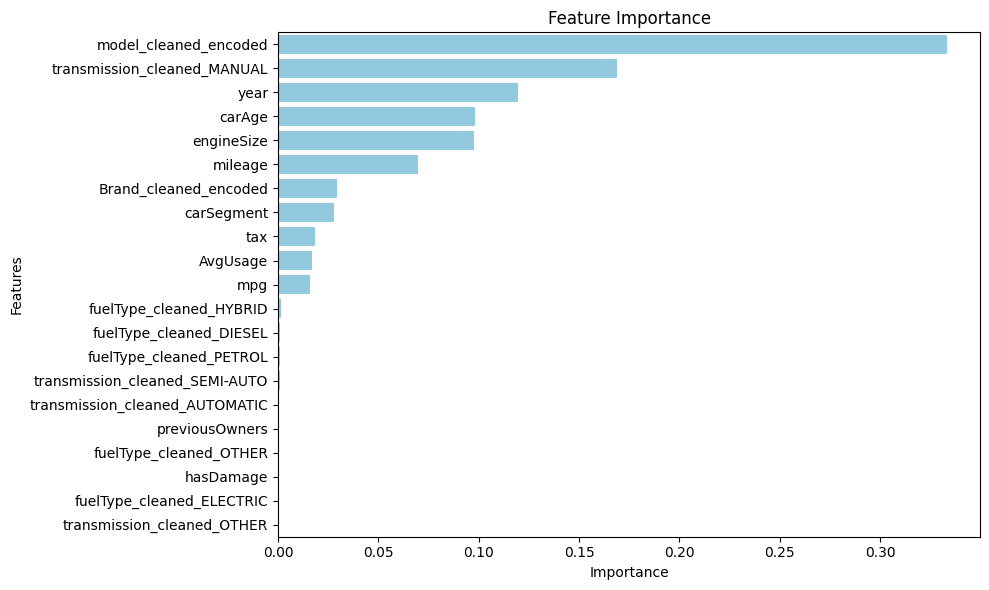

In [130]:

importance_pipeline = Pipeline([
    ('categorical treatment', Categorical_Correction()),  
    ('outlier treatment', Outlier_Treatment()),                   
    ('missing value treatment', Missing_Value_Treatment()),
    ('typecasting', Typecasting()), 
    ('feature engineering', Feature_Engineering()),
    ('encoder', Encoder() ), 
    ('scaler', Scaler(scaler=RobustScaler())), 
    ('regressor', TransformedTargetRegressor(regressor=GradientBoostingRegressor(**parameters_model),
                                                func=np.log, inverse_func=np.exp))
])

importance_pipeline = importance_pipeline.fit(X,y)

feature_importance = importance_pipeline.named_steps['regressor'].regressor_.feature_importances_ 
feature_names = importance_pipeline.named_steps['scaler'].feats_names_

# creating a dataframe of features and corresponding importance
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
# sorting the dataframe by importance in descending order for clearer visualization
importance_df = importance_df.sort_values(by='Importance', ascending=False) 
# visualizing importance
plt.figure(figsize=(10, 6))
sns.barplot(x=importance_df['Importance'], y=importance_df['Feature'], color="skyblue")
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

Feature importance values show that model_cleaned_encoded, which came from target encoding model_cleaned, is the highest contributing feature to the final model, followed by year and transmission_cleaned_MANUAL and year. carAge and engineSize show similar importance. After that, mileage, brand_cleaned_encoded, carSegment, tax, AvgUsage, mpg show lower but still significant impact and the remaining features had almost no contribution.

We will now obtain SHAP values for each feature in order to see how it affects price predictions (how much and in which direction).

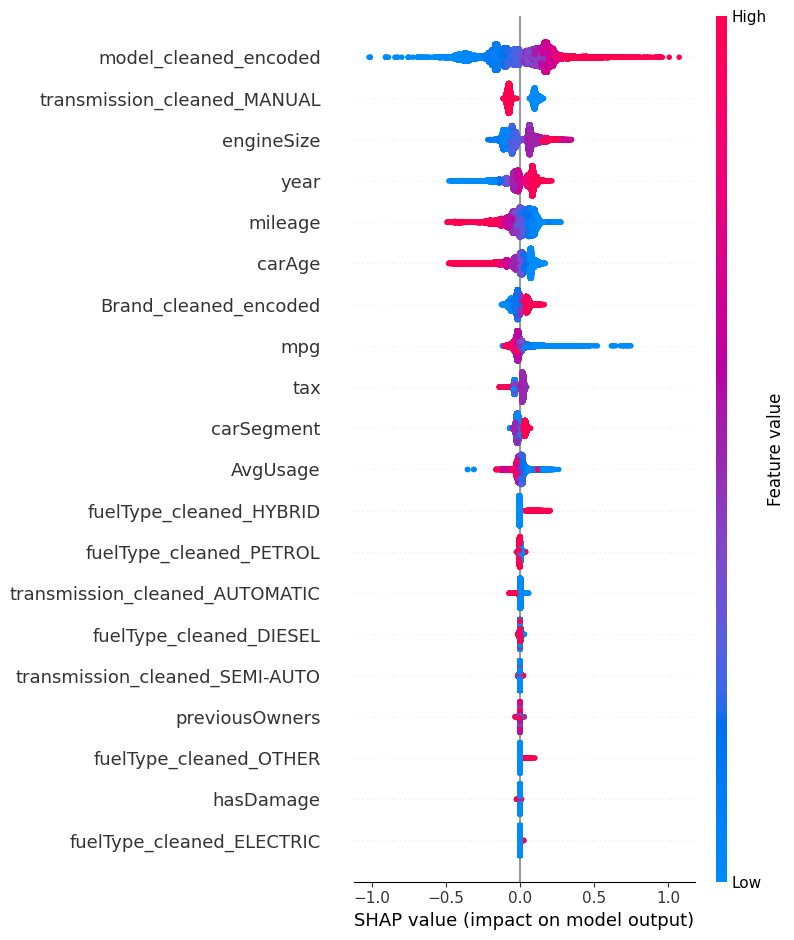

In [ ]:
#np.bool = bool <------ IF CELL FAILS TO RUN, UNCOMMENT THIS PLEASE

# getting the previous pipeline without the last step, i.e. keeping the transformers and excluding the regressor
preprocessor = Pipeline(importance_pipeline.steps[:-1])

# applying the new pipeline to train set to get pre-processed data
X_processed = preprocessor.transform(X)

# creating a shap TreeExplainer for the regressor
explainer = shap.TreeExplainer(importance_pipeline.named_steps['regressor'].regressor_)

# getting shap values by passing processed data into the explainer
shap_values = explainer.shap_values(X_processed)

shap.summary_plot(shap_values, X_processed)

The features with major impact according to the SHAP values are the same as before. Addditionally, we can now distinguish in which direction they impact the model. For example, higher/lower model_cleaned_encoded values tend to increase/decrease predictions. Lower mpg values tend to increase the price predictions which is consistent with what we found in EDA and also with real life standards (cars with less usage have higher prices).

We will now divide the target variable (price) into four bins, corresponding to low, medium-low, medium-high and high price values. For each of them we will compute the mean absolute SHAP value for each feature and see if the importances correspond to those extracted from the model itself.

In [ ]:
y_labels = ['low', 'medium-low', 'medium-high', 'high'] 
y_bins, bin_edges = pd.cut(y, bins=4, labels=y_labels, retbins=True)
bin_edges 

array([   290.451,  40337.25 ,  80224.5  , 120111.75 , 159999.   ])

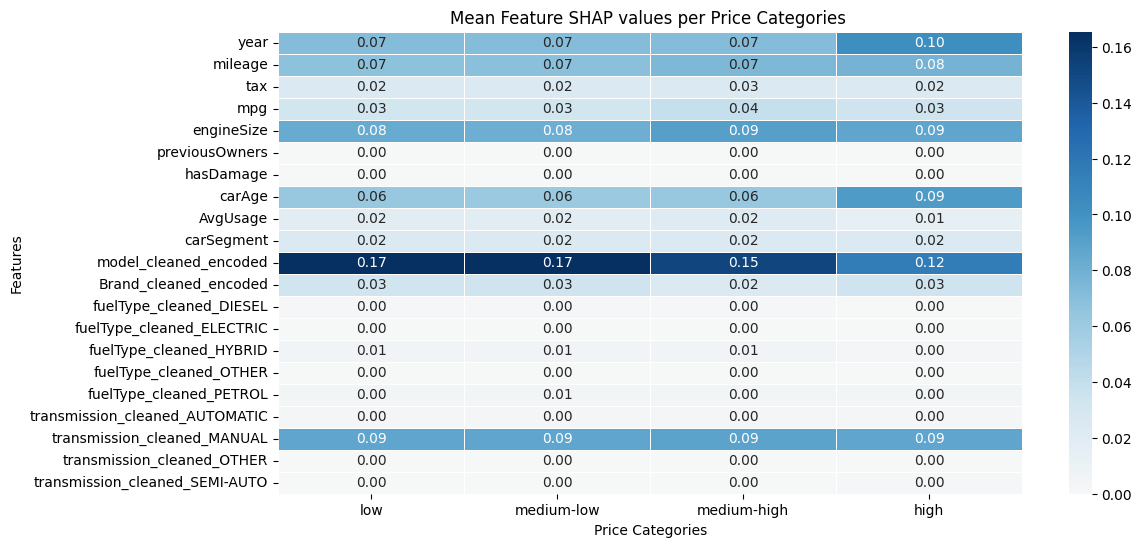

In [133]:

# converting shap values with features to dataframe for convenience
shap_df = pd.DataFrame(shap_values, columns=feature_names)

# computing absolute mean shap value for each feature in each bin
mean_shap_per_bin = shap_df.abs().groupby(y_bins).mean()

# heatmap for visualization
plt.figure(figsize=(12,6))
sns.heatmap(mean_shap_per_bin.T, cmap="RdBu", annot=True, fmt=".2f", linewidths=0.5, cbar=True, center=0)
plt.xlabel("Price Categories")
plt.ylabel("Features")
plt.title("Mean Feature SHAP values per Price Categories ")
plt.show()


From the heatmap, we can see that model_cleaned_encoded is by far still the feature with most importance across all bins. engineSize, transmission_cleaned_MANUAL, engineSize, year, mileage and carAge follow, with lower values in comparison to model_cleaned_encoded but similar values among them. The remaining features show lower importance. This is in accordance with the results from the feature importance bar plot previously shown.

Finally, let us check which features our model selects when we do not skip the feature selection step.

In [141]:
selection_pipeline = Pipeline([
    ('categorical treatment', Categorical_Correction()),  
    ('outlier treatment', Outlier_Treatment()),                   
    ('missing value treatment', Missing_Value_Treatment()),
    ('typecasting', Typecasting()), 
    ('feature engineering', Feature_Engineering()),
    ('encoder', Encoder() ), 
    ('scaler', Scaler(scaler=RobustScaler())), 
    ('feature selection', Feature_Selection(spearman_thr=0.2, rfe_k=11)),
    ('regressor', TransformedTargetRegressor(regressor=GradientBoostingRegressor(**parameters_model),
                                                func=np.log, inverse_func=np.exp))
])

selection_pipeline = selection_pipeline.fit(X,y)

selected = selection_pipeline.named_steps['feature selection'].selected_features_

print('Selected Features:', selected)



Selected Features: ['year', 'mileage', 'mpg', 'engineSize', 'carAge', 'carSegment', 'model_cleaned_encoded', 'Brand_cleaned_encoded', 'fuelType_cleaned_DIESEL', 'transmission_cleaned_MANUAL']


From the selected features, only fuelType_cleaned_DIESEL is present in the features with very low importance.